EDA 

In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"
df = pd.read_csv(url)
df.head()            

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Limpieza de Nulos y duplicados 

In [15]:
df.isnull().sum()
df.duplicated().sum()

np.int64(1)

Analisis categoricos 


sex:
 sex
male      676
female    662
Name: count, dtype: int64


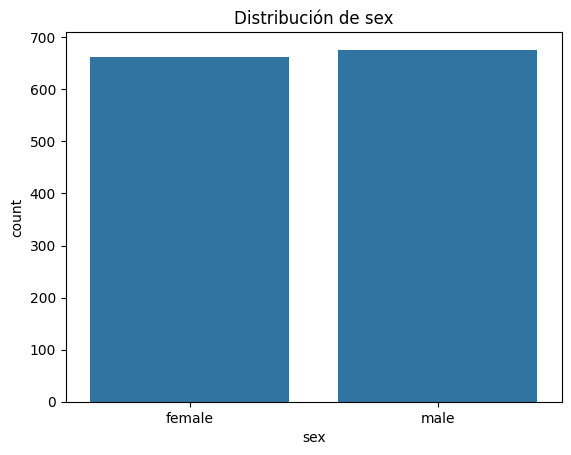


smoker:
 smoker
no     1064
yes     274
Name: count, dtype: int64


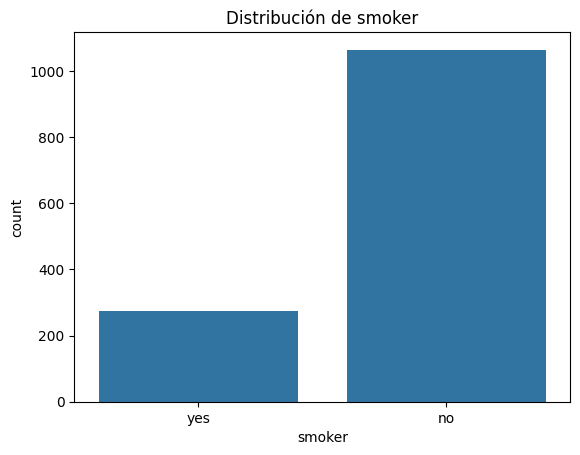


region:
 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


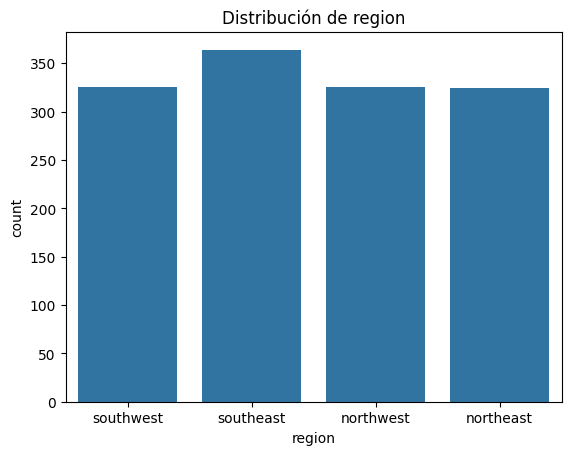

In [16]:
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.show()

Histogramas de edades 

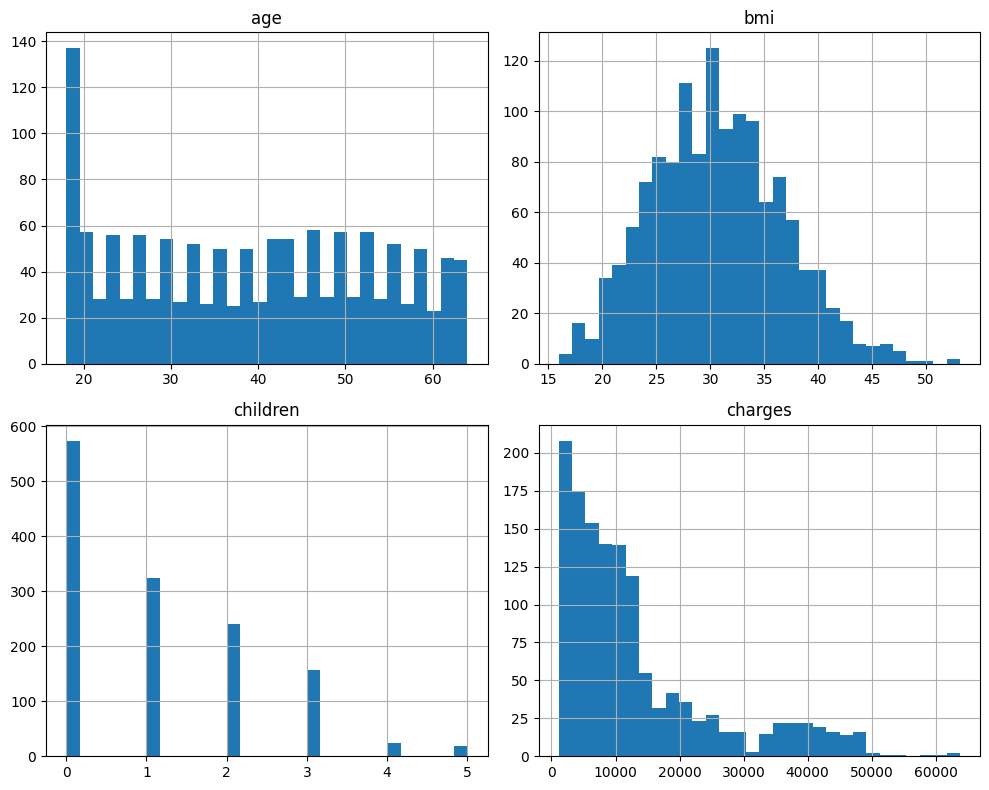

In [17]:
df[['age', 'bmi', 'children', 'charges']].hist(bins=30, figsize=(10, 8))
plt.tight_layout()
plt.show()

# RELACIONES UTILES


 Comparar fumadores y costos


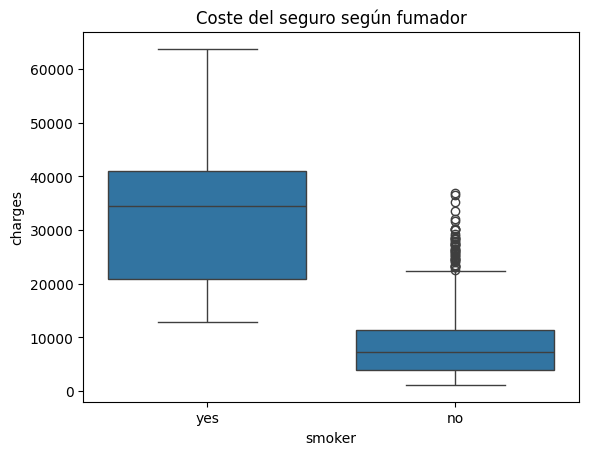

In [18]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Coste del seguro según fumador")
plt.show()

Coste VS edad

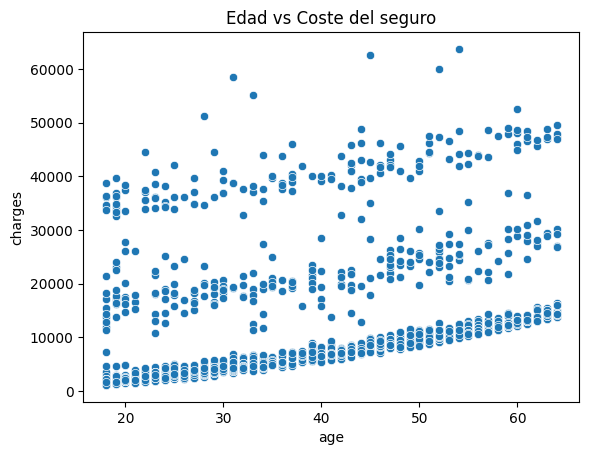

In [19]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Edad vs Coste del seguro")
plt.show()

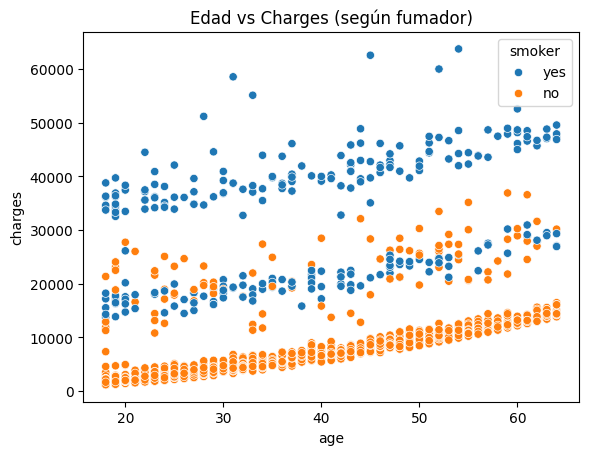

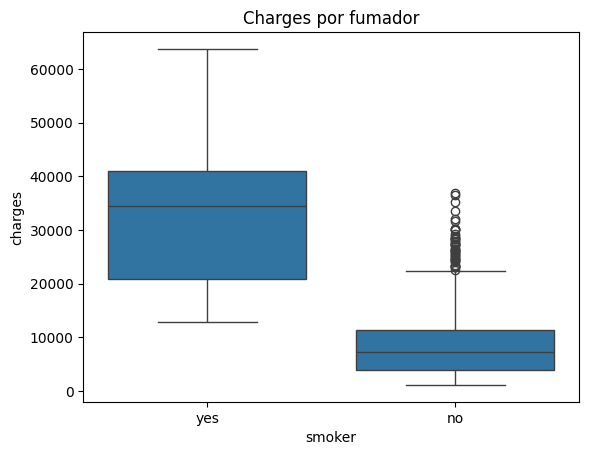

In [20]:
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title("Edad vs Charges (según fumador)")
plt.show()


sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges por fumador")
plt.show()

Divicion entre test y train 

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)


X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]


# Dividir 80% train - 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirmamos tamaños
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (1070, 8)
Tamaño de X_test: (268, 8)


CONCLUSIONES DEL EDA

No hay valores nulos ni duplicados.
Las variables categóricas están limpias y fueron codificadas.
Variables como smoker y age tienen clara relación con charges.
El dataset está listo para modelado.

In [25]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


mse, r2

(33596915.851361446, 0.7835929767120724)

Resultado

In [26]:
pd.DataFrame({
    'MSE (Error medio)': [mse],
    'R² (Precisión)': [r2]
})

,MSE (Error medio),R² (Precisión)
0,3.359692e+07,0.783593


Modelo de regresión lineal
Dividimos los datos en entrenamiento (80%) y prueba (20%), creamos un modelo de regresión lineal simple para predecir el costo del seguro (charges).Evaluamos el modelo con métricas:

MSE (error medio) → nos dice cuánto se equivoca el modelo.

R² (precisión) → nos dice qué tan bien el modelo explica los resultados.

Obtuvo un buen rendimiento inicial, lo que significa que el modelo aprendió una relación útil entre las variables y el costo del seguro.